In [1]:
import seaborn as sns
import pandas as pd

# Step 1: Load the taxis dataset
df = sns.load_dataset("taxis")

# Step 2: Display the first 5 rows
print(df.head())

# Step 3: Check basic info
print(df.info())

# Step 4: Get summary statistics
print(df.describe())


               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [2]:
# Count missing values per column
print(df.isnull().sum())


pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [4]:
# Numerical imputation
df['fare'] = df['fare'].fillna(df['fare'].mean())
df['tip'] = df['tip'].fillna(df['tip'].median())
df['passengers'] = df['passengers'].fillna(df['passengers'].mode()[0])

# Categorical imputation
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])
df['pickup_zone'] = df['pickup_zone'].fillna(df['pickup_zone'].mode()[0])
df['dropoff_zone'] = df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0])
df['pickup_borough'] = df['pickup_borough'].fillna(df['pickup_borough'].mode()[0])
df['dropoff_borough'] = df['dropoff_borough'].fillna(df['dropoff_borough'].mode()[0])

# Drop rows with missing critical values
df = df.dropna(subset=['pickup', 'dropoff'])

# Verify
print(df.isnull().sum())


pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


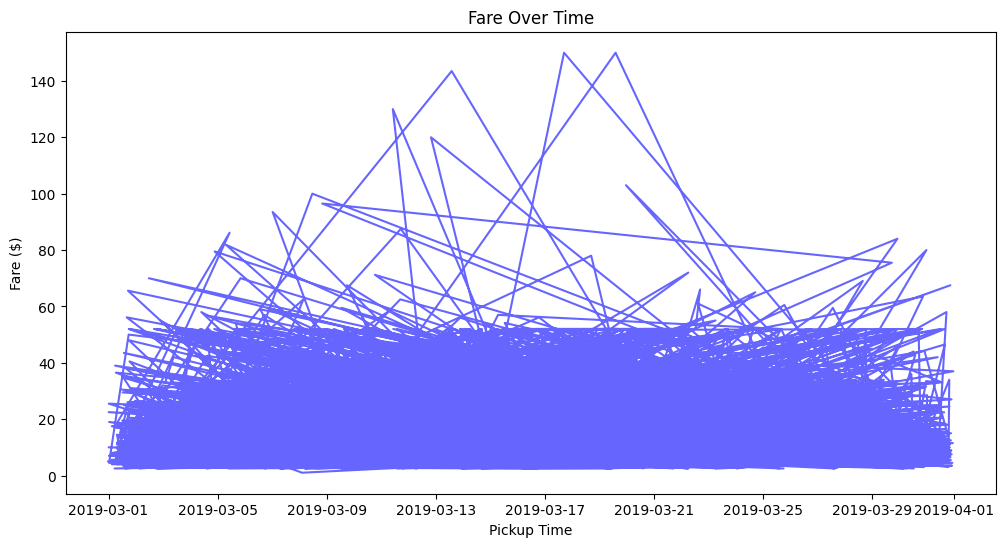

In [5]:
import matplotlib.pyplot as plt

# Ensure pickup is datetime
df['pickup'] = pd.to_datetime(df['pickup'])

plt.figure(figsize=(12,6))
plt.plot(df['pickup'], df['fare'], color='blue', alpha=0.6)
plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare ($)")
plt.show()


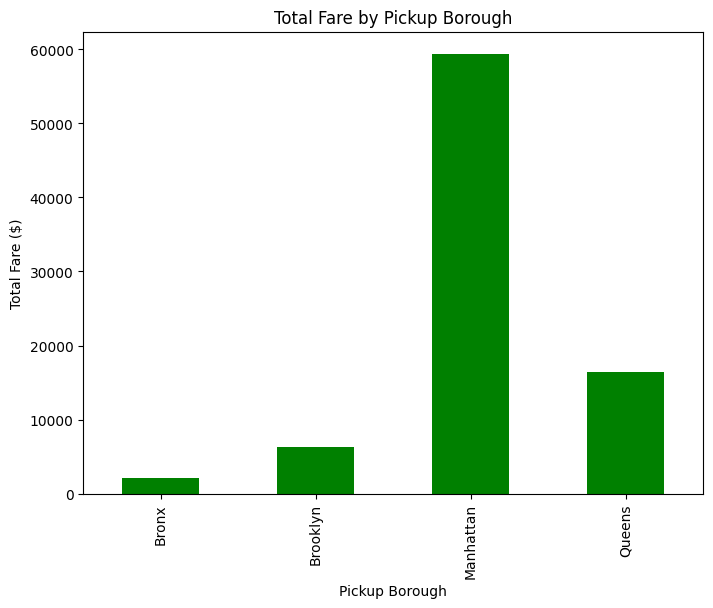

In [6]:
fare_by_borough = df.groupby('pickup_borough')['fare'].sum()

fare_by_borough.plot(kind='bar', color='green', figsize=(8,6))
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare ($)")
plt.show()


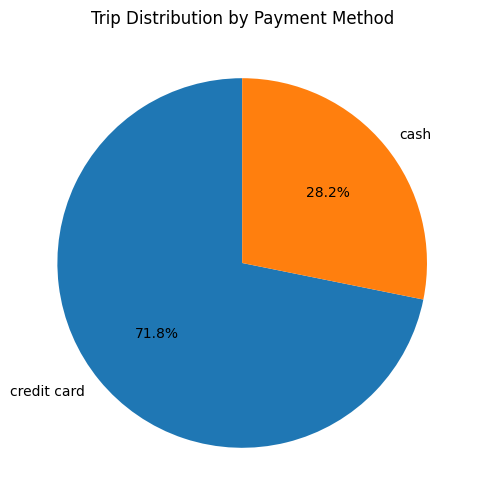

In [7]:
payment_counts = df['payment'].value_counts()

payment_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(6,6))
plt.title("Trip Distribution by Payment Method")
plt.ylabel("")  # Hide y-label
plt.show()


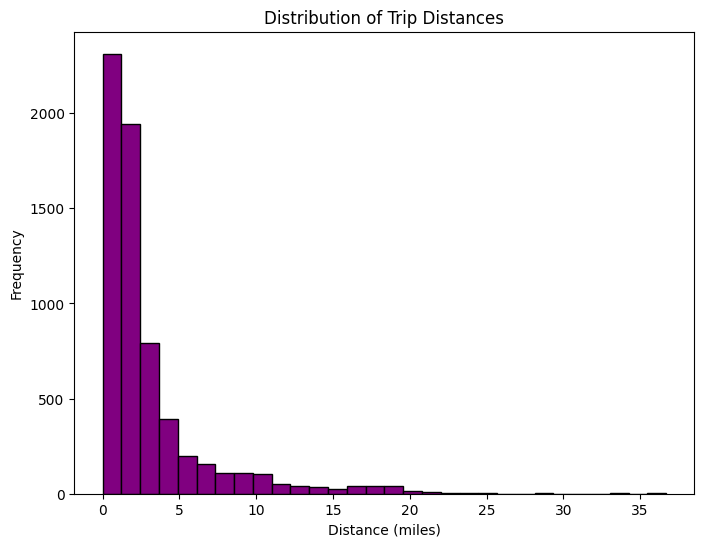

In [8]:
plt.figure(figsize=(8,6))
plt.hist(df['distance'], bins=30, color='purple', edgecolor='black')
plt.title("Distribution of Trip Distances")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.show()


<Figure size 1000x600 with 0 Axes>

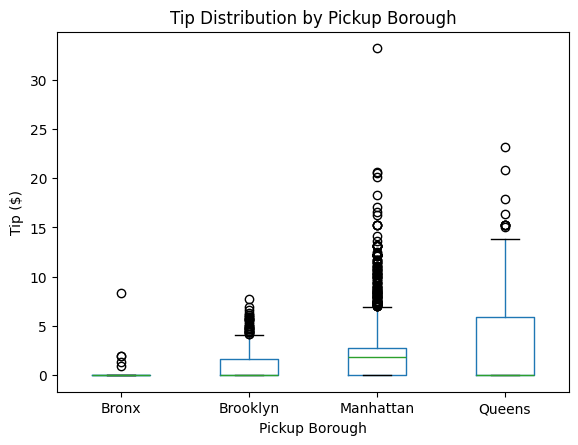

In [9]:
plt.figure(figsize=(10,6))
df.boxplot(column='tip', by='pickup_borough', grid=False)
plt.title("Tip Distribution by Pickup Borough")
plt.suptitle("")  # Remove automatic title
plt.xlabel("Pickup Borough")
plt.ylabel("Tip ($)")
plt.show()


/tmp/ipykernel_556/1572332261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="pickup_borough", data=df, palette="Set2")


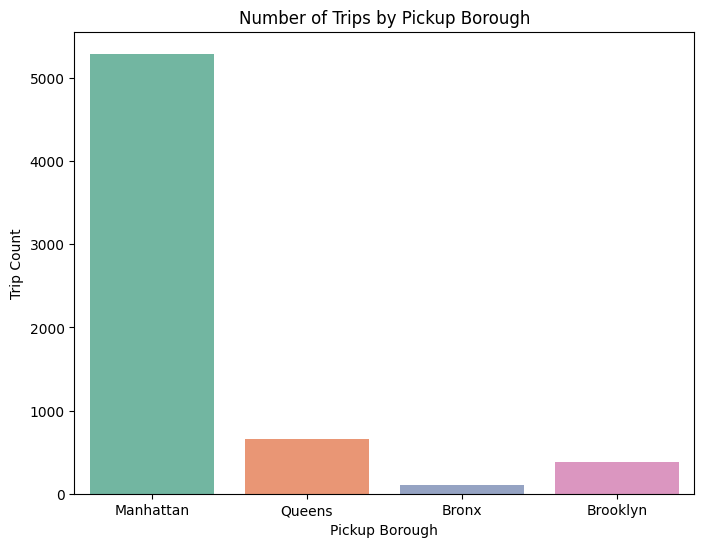

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(x="pickup_borough", data=df, palette="Set2")
plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Trip Count")
plt.show()


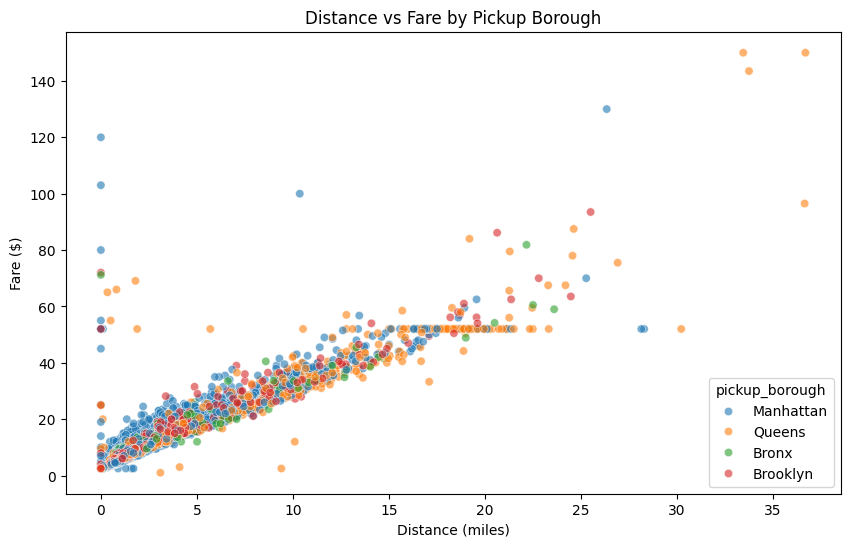

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="distance", y="fare", hue="pickup_borough", data=df, alpha=0.6)
plt.title("Distance vs Fare by Pickup Borough")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.show()


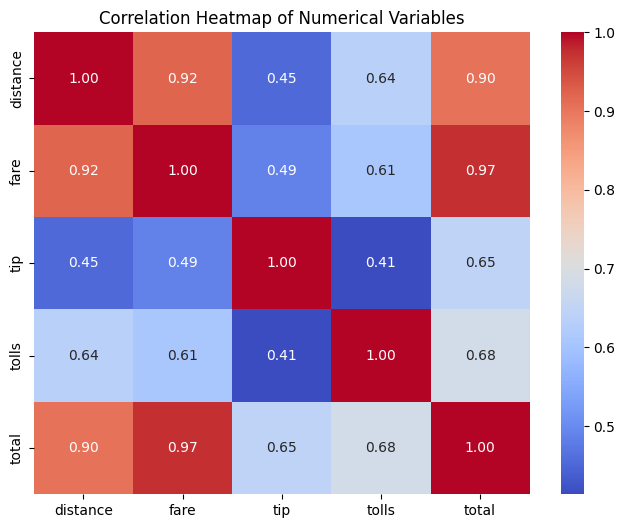

In [12]:
# Select numerical columns
num_cols = ["distance", "fare", "tip", "tolls", "total"]
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


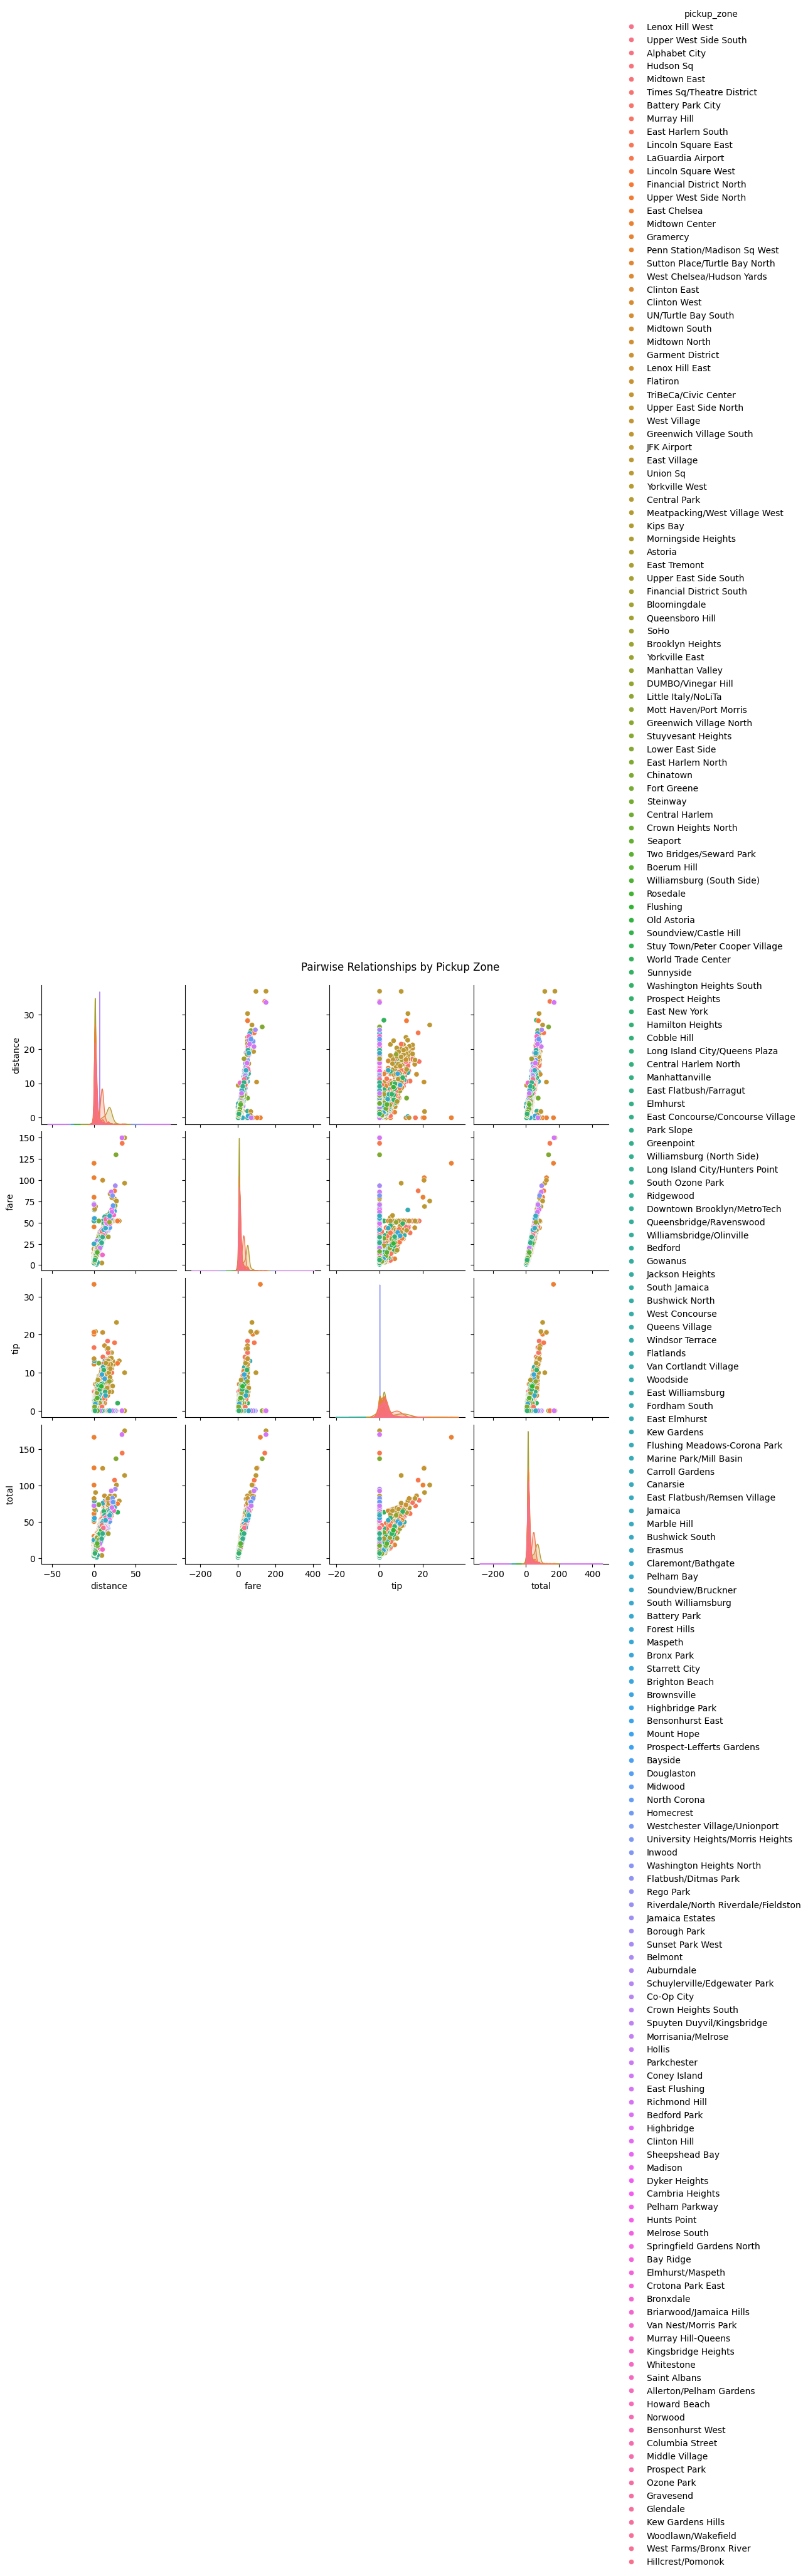

In [13]:
sns.pairplot(df[["distance","fare","tip","total","pickup_zone"]],
             hue="pickup_zone", diag_kind="kde", palette="husl")
plt.suptitle("Pairwise Relationships by Pickup Zone", y=1.02)
plt.show()


<Axes: xlabel='payment', ylabel='fare'>

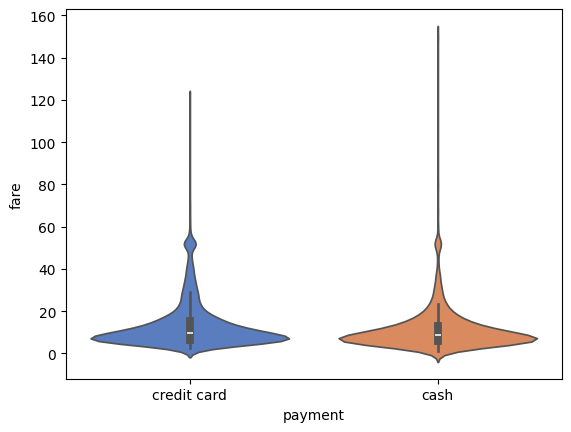

In [15]:
sns.violinplot(x="payment", y="fare", hue="payment", data=df,
               palette="muted", legend=False)
